# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age, fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



In [1]:
import pandas as pd

df = pd.read_csv('titanic_passengers.csv')

df.head(25)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [3]:
import pandas as pd
df = pd.read_csv('titanic_passengers.csv')

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [6]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [8]:
df.groupby(pd.cut(df['Age'], bins=[0,12,18,35,60,100]))['Survived'].mean()

C:\Users\fortu\AppData\Local\Temp\ipykernel_40852\2538951532.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['Age'], bins=[0,12,18,35,60,100]))['Survived'].mean()


Age
(0, 12]      0.579710
(12, 18]     0.428571
(18, 35]     0.382682
(35, 60]     0.400000
(60, 100]    0.227273
Name: Survived, dtype: float64

In [9]:
df.groupby(pd.qcut(df['Fare'], 4))['Survived'].mean()

C:\Users\fortu\AppData\Local\Temp\ipykernel_40852\3298163307.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df['Fare'], 4))['Survived'].mean()


Fare
(-0.001, 7.91]     0.197309
(7.91, 14.454]     0.303571
(14.454, 31.0]     0.454955
(31.0, 512.329]    0.581081
Name: Survived, dtype: float64

In [10]:
df.groupby(df['SibSp'] + df['Parch'])['Survived'].mean()

0     0.303538
1     0.552795
2     0.578431
3     0.724138
4     0.200000
5     0.136364
6     0.333333
7     0.000000
10    0.000000
Name: Survived, dtype: float64

In [14]:
df.groupby('Embarked')['Survived'].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

<Axes: title={'center': 'Survival Rate by Port of Departure'}, xlabel='Embarked'>

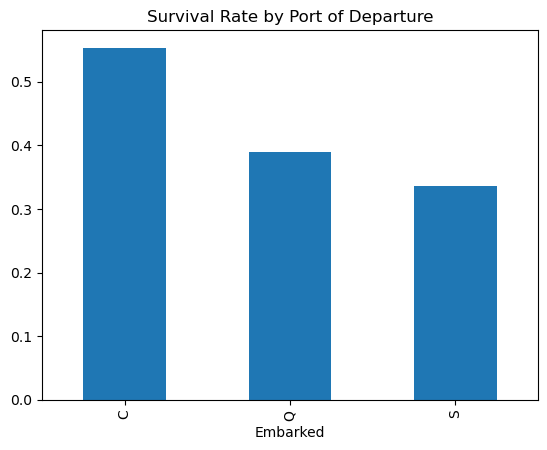

In [15]:
df.groupby('Embarked')['Survived'].mean().plot(kind='bar', title='Survival Rate by Port of Departure')

### Most Likely to Survive

Based on the data analysis, the profile most likely to survive the Titanic disaster includes the following characteristics:

- Female passengers had the highest survival rate (~74%)

- First-class passengers had significantly higher survival (~63%)

- Passengers aged 0-12 had the highest survival rate among age groups (~58%), and younger passengers overall tended to survive more often thsan older individuals

- Higher fare passengers had better survival outcomes

- Passengers traveling with small families (1–3 members) had higher survival rates

- Passengers who embarked from port C had the highest survival rate (~55%)

Combining these factors, the ideal profile is:

A young female passenger in first class, traveling with a small family, paying a high fare, and embarking from port C.

### Least Likely to Survive

Based on the data analysis, the profile least likely to survive includes:

- Male passengers had the lowest survival rate (~19%)

- Third-class passengers had the lowest survival (~24%)

- Passengers aged 60+ had lowest survival rate among age groups (~23%)

- Lower fare passengers had worse survival outcomes

- Passengers traveling alone or with large families had lower survival rates

- Passengers who embarked from port S had the lowest survival rate (~34%)

Combining these factors, the ideal profile is:

An older male passenger in third class, traveling alone, paying a low fare, and embarking from port S.

In [19]:
df['FamilySize'] = df['SibSp'] + df['Parch']
df[
    (df['Sex'] == 'female') &
    (df['Pclass'] == 1) &
    (df['Embarked'] == 'C') &
    (df['FamilySize'].between(1, 3))
].sort_values(by='Age').head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
329,330,1,1,"Hippach, Miss. Jean Gertrude",female,16.0,0,1,111361,57.9792,B18,C,1
307,308,1,1,"Penasco y Castellana, Mrs. Victor de Satode (M...",female,17.0,1,0,PC 17758,108.9000,C65,C,1
700,701,1,1,"Astor, Mrs. John Jacob (Madeleine Talmadge Force)",female,18.0,1,0,PC 17757,227.5250,C62 C64,C,1
291,292,1,1,"Bishop, Mrs. Dickinson H (Helen Walton)",female,19.0,1,0,11967,91.0792,B49,C,1
539,540,1,1,"Frolicher, Miss. Hedwig Margaritha",female,22.0,0,2,13568,49.5000,B39,C,2


A real passenger who closely matches the "most likely to survive" profile is Hippach, Miss. Jean Gertrude. She was a 16-year-old female traveling in first class and embarked from port C. She also paid a relatively high fare and was traveling with a small family, matching several of the strongest survival indicators. While she is slightly older than the highest-survival age group (0–12), she still aligns closely with the overall trend that younger passengers had higher survival rates. Her characteristics strongly match the ideal profile associated with the highest probability of survival.

In [20]:
df[
    (df['Sex'] == 'male') &
    (df['Pclass'] == 3) &
    (df['Embarked'] == 'S') &
    (df['Age'] >= 40)
].sort_values(by='Fare').head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
597,598,0,3,"Johnson, Mr. Alfred",male,49.0,0,0,LINE,0.0000,NaN,S,0
326,327,0,3,"Nysveen, Mr. Johan Hansen",male,61.0,0,0,345364,6.2375,NaN,S,0
818,819,0,3,"Holm, Mr. John Fredrik Alexander",male,43.0,0,0,C 7075,6.4500,NaN,S,0
129,130,0,3,"Ekstrom, Mr. Johan",male,45.0,0,0,347061,6.9750,NaN,S,0
631,632,0,3,"Lundahl, Mr. Johan Svensson",male,51.0,0,0,347743,7.0542,NaN,S,0


A real passenger who fits the "least likely to survive" profile is Nysveen, Mr. Johan Hansen. He was a 61-year-old male traveling in third class who embarked from port S. He paid a low fare and was traveling alone, aligning with multiple factors associated with low survival rates. This example reflects how being male, older, in a lower class, and having fewer resources significantly reduced the chances of survival.

### Additional Insight (Most Likely to Survive)

An interesting fact about Hippach, Miss. Jean Gertrude is that she and her mother were initially told to return to their room after the iceberg collision, as officers believed there was no immediate danger. Later, they were personally encouraged by Colonel John Jacob Astor to board Lifeboat 4, a decision that ultimately saved their lives.

### Additional Insight (Least Likely to Survive)

An interesting fact about Nysveen, Mr. Johan Hansen is that he was not originally planning to travel on the Titanic, and his wife did not know what happened to him until weeks after the disaster, when official passenger lists were released.